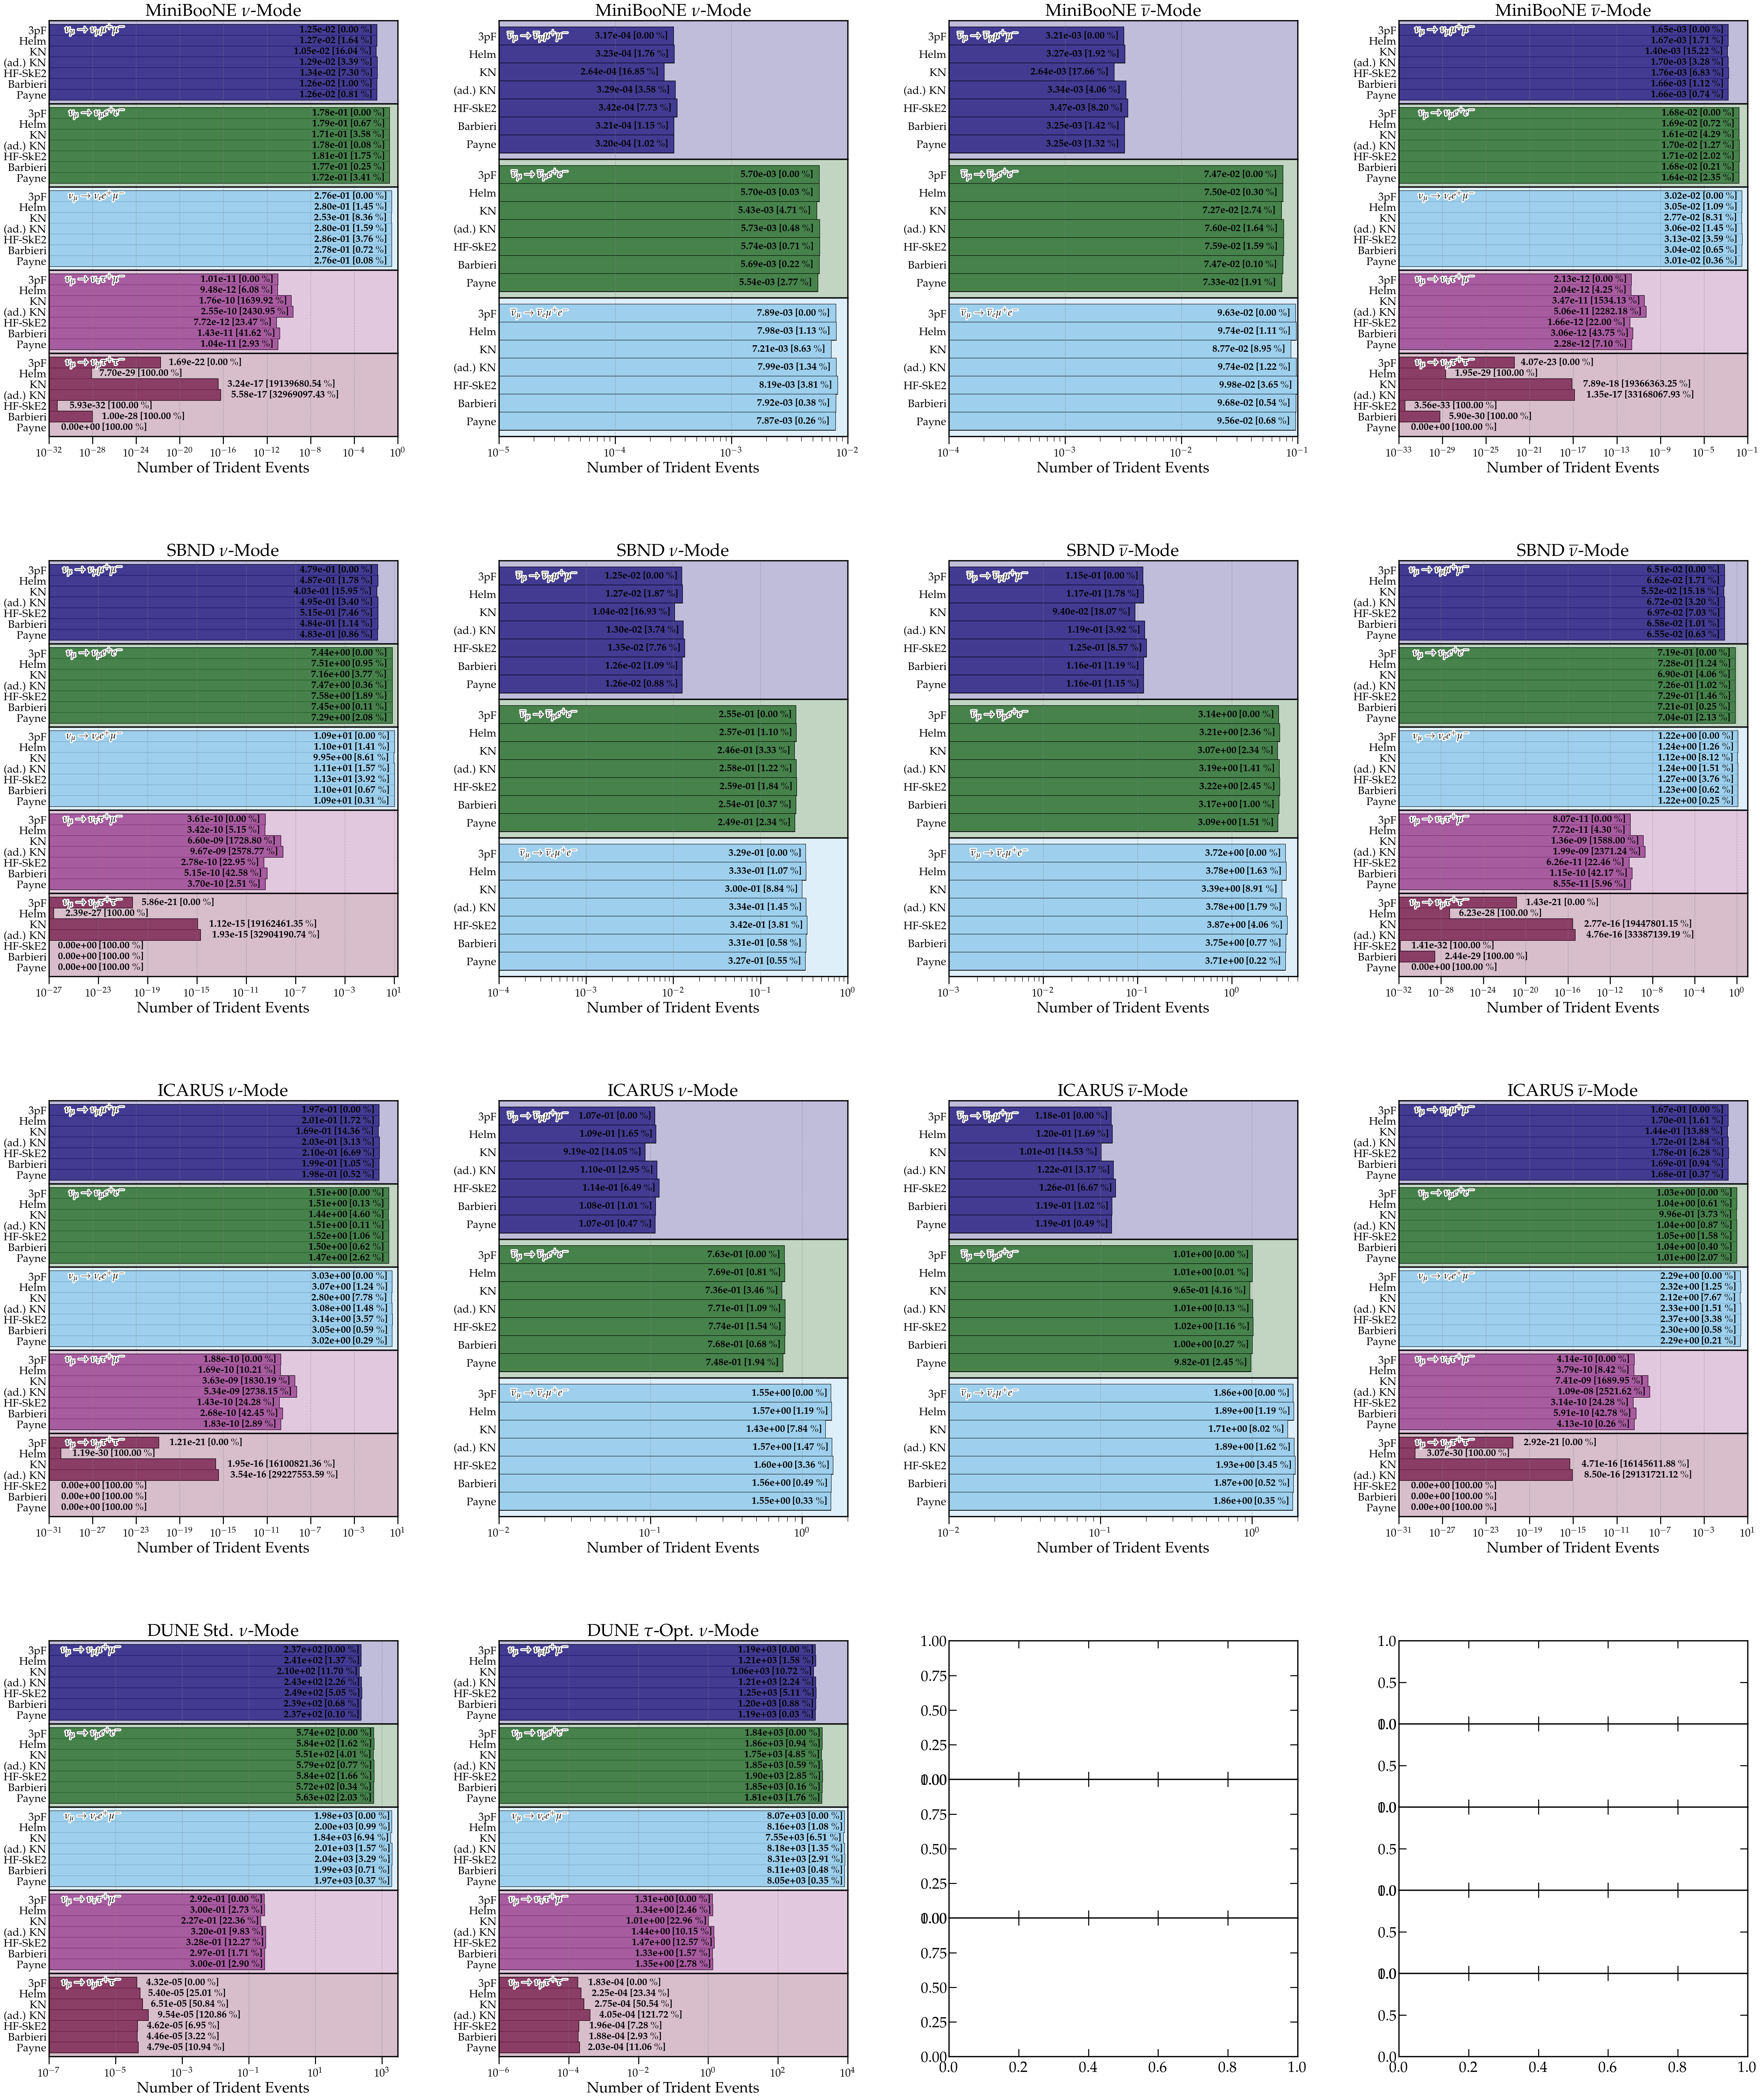

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib as mpl

plt.style.use('sty.mplstyle')

atomic_mass_unit = 1.6605e-27 # kg
MAr = 39.95*atomic_mass_unit # Mass of argon in atomic mass units

#=============================================================================
#=============================================================================

def Events_Uncertainties(convXsec, MD, Int_Flux, POT):
    # convXsec should be given in fb
    # MD should be given in tonnes
    # POT should be given in units of 10^{21}
    # Int_Flux should be given in nu/m^2/POT
    Uncertainty = np.zeros_like(convXsec)
    for i in range(len(convXsec)):
        for j in range(len(convXsec[i])):
            Uncertainty[i][j] = 100*np.abs( 1 - convXsec[i][j]/convXsec[i][0] )
    NumOfEvents = Int_Flux * convXsec * MD/MAr * POT
    NumOfEvents = 1e-19*NumOfEvents
    return NumOfEvents, Uncertainty

#=============================================================================
#=============================================================================

def PlotNumOfEvents(NumOfEvents, Uncertainty, FF, Process, figsize, cols, CP, xy_text, title, lim, fig, ax):
    Num_FF = len(FF)
    Num_Process = len(Process)
    #fig = plt.figure(figsize=figsize)
    #gs = fig.add_gridspec(Num_Process, hspace=0)
    #ax = gs.subplots(sharex=True, sharey=True)
    for i in range(len(NumOfEvents)):
        data = NumOfEvents[i]
        ax[i].barh(np.flipud(FF), np.flipud(data), left=0, align='center', height=1, edgecolor='k', facecolor='w', lw=1.5, zorder=-10, alpha=1)
        ax[i].barh(np.flipud(FF), np.flipud(data), left=0, xerr=0, align='center', height=0.98, facecolor=cols[i], lw=0, zorder=-10, alpha=0.9)
        ax[i].patch.set_facecolor(cols[i])
        ax[i].patch.set_alpha(0.3)
        ax[i].tick_params(axis='y', labelsize=22, left=False, pad=-10)
        ax[i].tick_params(axis='x', labelsize=22)
    
    for i in range(len(NumOfEvents)):
        for j in range(len(NumOfEvents[0])):
            if (NumOfEvents[i][j] != 0):
                ax[i].text(CP[i][j] * NumOfEvents[i][j], Num_FF-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                           (NumOfEvents[i][j], Uncertainty[i][j]), va='center', ha='right', fontsize=20)
            else:
                ax[i].text(CP[i][j], Num_FF-1-j, r'{\bf %.2e [%.2f $\%%$]}' %
                           (NumOfEvents[i][j], Uncertainty[i][j]), va='center', ha='right', fontsize=20)

    for i in range(len(ax)):
        ax[i].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.55)
        ax[i].tick_params(which='both', right=False, tickdir='out', top=False, bottom=False)
    ax[-1].tick_params(which='both', right=False, tickdir='out', top=False, bottom=True)

    for i in range(Num_Process):
        ax[i].text(xy_text[0], xy_text[1], Process[i], fontsize=20, alpha=1, color='k', va='center', ha='right', rotation=0, path_effects=[pe.Stroke(linewidth=5, foreground='w', alpha=1), pe.Normal()])

    ax[0].set_title(title, fontsize=35)
    ax[-1].set_xlabel(r'Number of Trident Events', fontsize=30)
    ax[-1].set_xscale('log')
    ax[-1].set_xlim(left=lim[0], right=lim[1])
    
    return fig, ax

BIG_fig = plt.figure(figsize=(50, 60))   # Big figure
BIG_subfigs = BIG_fig.subfigures(4, 4)                                # 4x4 grid of subfigures
BIG_fig.subplots_adjust(wspace=0.0, hspace=0.0)
layout = [[5,3,3,5],[5,3,3,5],[5,3,3,5],[5,5,3,5]]
single_fig = []
axes_in_single_fig = []

for row in range(4):
    for col in range(4):
        subfig = BIG_subfigs[row][col]
        axes = subfig.subplots(layout[row][col], 1, sharex=True, sharey=True)
        subfig.subplots_adjust(hspace=0)
        single_fig.append(subfig)
        axes_in_single_fig.append(axes)

fig1_MiniBooNE, ax1_MiniBooNE = single_fig[0], axes_in_single_fig[0]
fig2_MiniBooNE, ax2_MiniBooNE = single_fig[1], axes_in_single_fig[1]
fig3_MiniBooNE, ax3_MiniBooNE = single_fig[2], axes_in_single_fig[2]
fig4_MiniBooNE, ax4_MiniBooNE = single_fig[3], axes_in_single_fig[3]

fig1_SBND, ax1_SBND = single_fig[4], axes_in_single_fig[4]
fig2_SBND, ax2_SBND = single_fig[5], axes_in_single_fig[5]
fig3_SBND, ax3_SBND = single_fig[6], axes_in_single_fig[6]
fig4_SBND, ax4_SBND = single_fig[7], axes_in_single_fig[7]

fig1_ICARUS, ax1_ICARUS = single_fig[8], axes_in_single_fig[8]
fig2_ICARUS, ax2_ICARUS = single_fig[9], axes_in_single_fig[9]
fig3_ICARUS, ax3_ICARUS = single_fig[10], axes_in_single_fig[10]
fig4_ICARUS, ax4_ICARUS = single_fig[11], axes_in_single_fig[11]

fig1_DUNE, ax1_DUNE = single_fig[12], axes_in_single_fig[12]
fig2_DUNE, ax2_DUNE = single_fig[13], axes_in_single_fig[13]

#=============================================================================
#=================== Number of Trident Events at MiniBooNE ===================
#=============================================================================

xy_text = (1e-25,6)
title = r'MiniBooNE $\nu$-Mode'
lim = (1e-32,1)
cols = ['#2E2585', '#337538', '#94CBEC', '#9F4A96', '#7E2954']
Form_Factors = ['3pF', 'Helm', 'KN', '(ad.) KN', 'HF-SkE2', 'Barbieri', 'Payne']
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [3e7, 2.5e8, 6e10, 8e10, 6e8, 3e8, 1e-23]]

POT_MiniBooNE = 0.66
MD_MiniBooNE = 112
Int_Flux_MiniBooNE = 5.188231179736934e-06
ConvXsec_NuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/MiniBooNE/ConvXsec_nuflux_nuMode_MiniBooNE')
NumOfEvents_NuFlux_NuMode_MiniBooNE, Uncertainty_NuFlux_NuMode_MiniBooNE = Events_Uncertainties(convXsec = ConvXsec_NuFlux_NuMode_MiniBooNE,
                                                                                                MD = MD_MiniBooNE,
                                                                                                Int_Flux = Int_Flux_MiniBooNE,
                                                                                                POT = POT_MiniBooNE)


fig1_MiniBooNE, ax1_MiniBooNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_NuMode_MiniBooNE,
                                                Uncertainty = Uncertainty_NuFlux_NuMode_MiniBooNE,
                                                FF = Form_Factors, Process = Processes, figsize = (12,20),
                                                cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                                fig=fig1_MiniBooNE, ax=ax1_MiniBooNE)
#plt.savefig(r'../Plots/Figures_PDF/MiniBooNE/EventsatMiniBooNE_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/MiniBooNE/EventsatMiniBooNE_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (4e-5,6)
title = r'MiniBooNE $\nu$-Mode'
lim = (1e-5,1e-2)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9]]

Int_Flux_MiniBooNE = 3.205341386277867e-07
ConvXsec_AntiNuFlux_NuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/MiniBooNE/ConvXsec_antinuflux_nuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_NuMode_MiniBooNE, Uncertainty_AntiNuFlux_NuMode_MiniBooNE = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_NuMode_MiniBooNE,
                                                                                                        MD = MD_MiniBooNE,
                                                                                                        Int_Flux = Int_Flux_MiniBooNE,
                                                                                                        POT = POT_MiniBooNE)


fig2_MiniBooNE, ax2_MiniBooNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_NuMode_MiniBooNE,
                                                Uncertainty = Uncertainty_AntiNuFlux_NuMode_MiniBooNE,
                                                FF = Form_Factors, Process = Processes, figsize = (12,14),
                                                cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                                fig=fig2_MiniBooNE, ax=ax2_MiniBooNE)
#plt.savefig(r'../Plots/Figures_PDF/MiniBooNE/EventsatMiniBooNE_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/MiniBooNE/EventsatMiniBooNE_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (4e-4,6)
title = r'MiniBooNE $\overline{\nu}$-Mode'
lim = (1e-4,1e-1)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']
CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9]]

Int_Flux_MiniBooNE = 2.924954142603493e-06
ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/MiniBooNE/ConvXsec_antinuflux_antinuMode_MiniBooNE')
NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE, Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_AntiNuMode_MiniBooNE,
                                                                                                                MD = MD_MiniBooNE,
                                                                                                                Int_Flux = Int_Flux_MiniBooNE,
                                                                                                                POT = POT_MiniBooNE)


fig3_MiniBooNE, ax3_MiniBooNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_AntiNuMode_MiniBooNE,
                                                Uncertainty = Uncertainty_AntiNuFlux_AntiNuMode_MiniBooNE,
                                                FF = Form_Factors, Process = Processes, figsize = (12,14),
                                                cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                                fig=fig3_MiniBooNE, ax=ax3_MiniBooNE)
#plt.savefig(r'../Plots/Figures_PDF/MiniBooNE/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/MiniBooNE/EventsatMiniBooNE_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (1e-26,6)
title = r'MiniBooNE $\overline{\nu}$-Mode'
lim = (1e-33,1e-1)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [2e7, 3e8, 9e10, 1e11, 3e8, 3e8, 1e-24]]

Int_Flux_MiniBooNE = 5.365346615405334e-07
ConvXsec_NuFlux_AntiNuMode_MiniBooNE = np.loadtxt('../csv/Conv_CrossSections/MiniBooNE/ConvXsec_nuflux_antinuMode_MiniBooNE')
NumOfEvents_NuFlux_AntiNuMode_MiniBooNE, Uncertainty_NuFlux_AntiNuMode_MiniBooNE = Events_Uncertainties(convXsec = ConvXsec_NuFlux_AntiNuMode_MiniBooNE,
                                                                                                        MD = MD_MiniBooNE,
                                                                                                        Int_Flux = Int_Flux_MiniBooNE,
                                                                                                        POT = POT_MiniBooNE)


fig4_MiniBooNE, ax4_MiniBooNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_AntiNuMode_MiniBooNE,
                                                Uncertainty = Uncertainty_NuFlux_AntiNuMode_MiniBooNE,
                                                FF = Form_Factors, Process = Processes, figsize = (12,20),
                                                cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                                fig=fig4_MiniBooNE, ax=ax4_MiniBooNE)
#plt.savefig(r'../Plots/Figures_PDF/MiniBooNE/EventsatMiniBooNE_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/MiniBooNE/EventsatMiniBooNE_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#====================== Number of Trident Events at SBND =====================
#=============================================================================

xy_text = (1e-21,6)
title = r'SBND $\nu$-Mode'
lim = (1e-27,20)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [5e6, 5e7, 5e9, 5e9, 5e-20, 5e-20, 5e-20]]

POT_SBND = 1.0
MD_SBND = 112
Int_Flux_SBND = 0.00016114069432666668
ConvXsec_NuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/SBND/ConvXsec_nuflux_nuMode_SBND')
NumOfEvents_NuFlux_NuMode_SBND, Uncertainty_NuFlux_NuMode_SBND = Events_Uncertainties(convXsec = ConvXsec_NuFlux_NuMode_SBND,
                                                                                      MD = MD_SBND,
                                                                                      Int_Flux = Int_Flux_SBND,
                                                                                      POT = POT_SBND)


fig1_SBND, ax1_SBND = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_NuMode_SBND,
                                      Uncertainty = Uncertainty_NuFlux_NuMode_SBND,
                                      FF = Form_Factors, Process = Processes, figsize = (12,20),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig1_SBND, ax=ax1_SBND)
#plt.savefig(r'../Plots/Figures_PDF/SBND/EventsatSBND_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/SBND/EventsatSBND_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (8e-4,6)
title = r'SBND $\nu$-Mode'
lim = (1e-4,1)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']

CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9]]

Int_Flux_SBND = 1.1709089422666665e-05
ConvXsec_AntiNuFlux_NuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/SBND/ConvXsec_antinuflux_nuMode_SBND')
NumOfEvents_AntiNuFlux_NuMode_SBND, Uncertainty_AntiNuFlux_NuMode_SBND = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_NuMode_SBND,
                                                                                              MD = MD_SBND,
                                                                                              Int_Flux = Int_Flux_SBND,
                                                                                              POT = POT_SBND)


fig2_SBND, ax2_SBND = PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_NuMode_SBND,
                                      Uncertainty = Uncertainty_AntiNuFlux_NuMode_SBND,
                                      FF = Form_Factors, Process = Processes, figsize = (12,14),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig2_SBND, ax=ax2_SBND)
#plt.savefig(r'../Plots/Figures_PDF/SBND/EventsatSBND_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/SBND/EventsatSBND_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (7e-3,6)
title = r'SBND $\overline{\nu}$-Mode'
lim = (1e-3,5)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']

CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9]]

Int_Flux_SBND = 8.782506499594861e-05
ConvXsec_AntiNuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/SBND/ConvXsec_antinuflux_antinuMode_SBND')
NumOfEvents_AntiNuFlux_AntiNuMode_SBND, Uncertainty_AntiNuFlux_AntiNuMode_SBND = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_AntiNuMode_SBND,
                                                                                                      MD = MD_SBND,
                                                                                                      Int_Flux = Int_Flux_SBND,
                                                                                                      POT = POT_SBND)


fig3_SBND, ax3_SBND = PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_AntiNuMode_SBND,
                                      Uncertainty = Uncertainty_AntiNuFlux_AntiNuMode_SBND,
                                      FF = Form_Factors, Process = Processes, figsize = (12,14),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig3_SBND, ax=ax3_SBND)
#plt.savefig(r'../Plots/Figures_PDF/SBND/EventsatSBND_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/SBND/EventsatSBND_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (5e-26,6)
title = r'SBND $\overline{\nu}$-Mode'
lim = (1e-32,10)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [6e7, 6e8, 2e11, 2e11, 8e8, 7e8, 2e-23]]

Int_Flux_SBND = 1.5891932893480667e-05
ConvXsec_NuFlux_AntiNuMode_SBND = np.loadtxt('../csv/Conv_CrossSections/SBND/ConvXsec_nuflux_antinuMode_SBND')
NumOfEvents_NuFlux_AntiNuMode_SBND, Uncertainty_NuFlux_AntiNuMode_SBND = Events_Uncertainties(convXsec = ConvXsec_NuFlux_AntiNuMode_SBND,
                                                                                              MD = MD_SBND,
                                                                                              Int_Flux = Int_Flux_SBND,
                                                                                              POT = POT_SBND)


fig4_SBND, ax4_SBND = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_AntiNuMode_SBND,
                                      Uncertainty = Uncertainty_NuFlux_AntiNuMode_SBND,
                                      FF = Form_Factors, Process = Processes, figsize = (12,20),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig4_SBND, ax=ax4_SBND)
#plt.savefig(r'../Plots/Figures_PDF/SBND/EventsatSBND_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/SBND/EventsatSBND_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#====================== Number of Trident Events at DUNE =====================
#=============================================================================

xy_text = (1.5e-5,6)
title = r'DUNE Std. $\nu$-Mode'
lim = (1e-7,3e3)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9],
      [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [3e2,4e2,4e2,6e2,3e2,3e2,4e2]]

POT_DUNE = 3.3
MD_DUNE = 67
Int_Flux_DUNE = 0.0010438734424042
ConvXsec_NuFlux_NuMode_DUNEStd = np.loadtxt('../csv/Conv_CrossSections/DUNE/ConvXsec_nuflux_nuMode_DUNEStd')
NumOfEvents_NuFlux_NuMode_DUNEStd, Uncertainty_NuFlux_NuMode_DUNEStd = Events_Uncertainties(convXsec = ConvXsec_NuFlux_NuMode_DUNEStd,
                                                                                            MD = MD_DUNE,
                                                                                            Int_Flux = Int_Flux_DUNE,
                                                                                            POT = POT_DUNE)


fig1_DUNE, ax1_DUNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_NuMode_DUNEStd,
                                      Uncertainty = Uncertainty_NuFlux_NuMode_DUNEStd,
                                      FF = Form_Factors, Process = Processes, figsize = (12,20),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig1_DUNE, ax=ax1_DUNE)
#plt.savefig(r'../Plots/Figures_PDF/DUNE/EventsatDUNEStd_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/DUNE/EventsatDUNEStd_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (1e-4,6)
title = r'DUNE $\tau$-Opt. $\nu$-Mode'
lim = (1e-6,1e4)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [0.9,0.9,0.9,0.9,0.9,0.9,0.9],
      [0.9,0.9,0.9,0.9,0.9,0.9,0.9], [2.5e2,3.5e2,3.5e2,4.5e2,2.5e2,2.5e2,3e2]]

Int_Flux_DUNE = 0.0011485658077633335
ConvXsec_NuFlux_NuMode_DUNETauOpt = np.loadtxt('../csv/Conv_CrossSections/DUNE/ConvXsec_nuflux_nuMode_DUNETauOpt')
NumOfEvents_NuFlux_NuMode_DUNETauOpt, Uncertainty_NuFlux_NuMode_DUNETauOpt = Events_Uncertainties(convXsec = ConvXsec_NuFlux_NuMode_DUNETauOpt,
                                                                                                  MD = MD_DUNE,
                                                                                                  Int_Flux = Int_Flux_DUNE,
                                                                                                  POT = POT_DUNE)


fig2_DUNE, ax2_DUNE = PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_NuMode_DUNETauOpt,
                                      Uncertainty = Uncertainty_NuFlux_NuMode_DUNETauOpt,
                                      FF = Form_Factors, Process = Processes, figsize = (12,20),
                                      cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                      fig=fig2_DUNE, ax=ax2_DUNE)
#plt.savefig(r'../Plots/Figures_PDF/DUNE/EventsatDUNETauOpt_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/DUNE/EventsatDUNETauOpt_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#============== Number of Trident Events at ICARUS NuMI Off-axis =============
#=============================================================================

xy_text = (1e-24,6)
title = r'ICARUS $\nu$-Mode'
lim = (1e-31,1e1)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [5e7,5e8,1e11,1e11,1e-22,1e-22,1e-22]]

POT_ICARUS = 1.8
MD_ICARUS = 476
Int_Flux_ICARUS = 5.0191785153474405e-06
ConvXsec_NuFlux_NuMode_ICARUS = np.loadtxt('../csv/Conv_CrossSections/ICARUS/ConvXsec_nuflux_nuMode_ICARUS')
NumOfEvents_NuFlux_NuMode_ICARUS, Uncertainty_NuFlux_NuMode_ICARUS = Events_Uncertainties(convXsec = ConvXsec_NuFlux_NuMode_ICARUS,
                                                                                          MD = MD_ICARUS,
                                                                                          Int_Flux = Int_Flux_ICARUS,
                                                                                          POT = POT_ICARUS)


fig1_ICARUS, ax1_ICARUS= PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_NuMode_ICARUS,
                                         Uncertainty = Uncertainty_NuFlux_NuMode_ICARUS,
                                         FF = Form_Factors, Process = Processes, figsize = (12,20),
                                         cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                         fig=fig1_ICARUS, ax=ax1_ICARUS)
#plt.savefig(r'../Plots/Figures_PDF/ICARUS/EventsatICARUS_NuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/ICARUS/EventsatICARUS_NuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (2.9e-2,6)
title = r'ICARUS $\nu$-Mode'
lim = (1e-2,2)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']

CP = [[0.95,0.95,0.95,0.95,0.95,0.95,0.95], [0.95,0.95,0.95,0.95,0.95,0.95,0.95], [0.95,0.95,0.95,0.95,0.95,0.95,0.95]]

Int_Flux_ICARUS = 2.6679782315159854e-06
ConvXsec_AntiNuFlux_NuMode_ICARUS = np.loadtxt('../csv/Conv_CrossSections/ICARUS/ConvXsec_antinuflux_nuMode_ICARUS')
NumOfEvents_AntiNuFlux_NuMode_ICARUS, Uncertainty_AntiNuFlux_NuMode_ICARUS = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_NuMode_ICARUS,
                                                                                                  MD = MD_ICARUS,
                                                                                                  Int_Flux = Int_Flux_ICARUS,
                                                                                                  POT = POT_ICARUS)


fig2_ICARUS, ax2_ICARUS= PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_NuMode_ICARUS,
                                         Uncertainty = Uncertainty_AntiNuFlux_NuMode_ICARUS,
                                         FF = Form_Factors, Process = Processes, figsize = (12,14),
                                         cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                         fig=fig2_ICARUS, ax=ax2_ICARUS)
#plt.savefig(r'../Plots/Figures_PDF/ICARUS/EventsatICARUS_AntiNuFlux_NuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/ICARUS/EventsatICARUS_AntiNuFlux_NuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (2.9e-2,6)
title = r'ICARUS $\overline{\nu}$-Mode'
lim = (1e-2,2)
Processes = [r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_\mu e^{+} e^{-}$}',
             r'{\bf $\overline{\nu}_\mu \to \overline{\nu}_e \mu^{+} e^{-}$}']

CP = [[0.95,0.95,0.95,0.95,0.95,0.95,0.95], [0.95,0.95,0.95,0.95,0.95,0.95,0.95], [0.95,0.95,0.95,0.95,0.95,0.95,0.95]]

Int_Flux_ICARUS = 4.294211997449354e-06
ConvXsec_AntiNuFlux_AntiNuMode_ICARUS = np.loadtxt('../csv/Conv_CrossSections/ICARUS/ConvXsec_antinuflux_antinuMode_ICARUS')
NumOfEvents_AntiNuFlux_AntiNuMode_ICARUS, Uncertainty_AntiNuFlux_AntiNuMode_ICARUS = Events_Uncertainties(convXsec = ConvXsec_AntiNuFlux_AntiNuMode_ICARUS,
                                                                                                          MD = MD_ICARUS,
                                                                                                          Int_Flux = Int_Flux_ICARUS,
                                                                                                          POT = POT_ICARUS)


fig3_ICARUS, ax3_ICARUS= PlotNumOfEvents(NumOfEvents = NumOfEvents_AntiNuFlux_AntiNuMode_ICARUS,
                                         Uncertainty = Uncertainty_AntiNuFlux_AntiNuMode_ICARUS,
                                         FF = Form_Factors, Process = Processes, figsize = (12,14),
                                         cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                         fig=fig3_ICARUS, ax=ax3_ICARUS)
#plt.savefig(r'../Plots/Figures_PDF/ICARUS/EventsatICARUS_AntiNuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/ICARUS/EventsatICARUS_AntiNuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

#=============================================================================
#=============================================================================

xy_text = (1e-24,6)
title = r'ICARUS $\overline{\nu}$-Mode'
lim = (1e-31,1e1)
Processes = [r'{\bf $\nu_\mu \to \nu_\mu \mu^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu e^{+} e^{-}$}',
             r'{\bf $\nu_\mu \to \nu_e e^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\tau \tau^{+} \mu^{-}$}',
             r'{\bf $\nu_\mu \to \nu_\mu \tau^{+} \tau^{-}$}']

CP = [[0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [0.4,0.4,0.4,0.4,0.4,0.4,0.4],
      [0.4,0.4,0.4,0.4,0.4,0.4,0.4], [5e7,5e8,1e11,1e11,1e-22,1e-22,1e-22]]

Int_Flux_ICARUS = 2.7713597014253004e-06
ConvXsec_NuFlux_AntiNuMode_ICARUS = np.loadtxt('../csv/Conv_CrossSections/ICARUS/ConvXsec_nuflux_antinuMode_ICARUS')
NumOfEvents_NuFlux_AntiNuMode_ICARUS, Uncertainty_NuFlux_AntiNuMode_ICARUS = Events_Uncertainties(convXsec = ConvXsec_NuFlux_AntiNuMode_ICARUS,
                                                                                                  MD = MD_ICARUS,
                                                                                                  Int_Flux = Int_Flux_ICARUS,
                                                                                                  POT = POT_ICARUS)


fig4_ICARUS, ax4_ICARUS= PlotNumOfEvents(NumOfEvents = NumOfEvents_NuFlux_AntiNuMode_ICARUS,
                                         Uncertainty = Uncertainty_NuFlux_AntiNuMode_ICARUS,
                                         FF = Form_Factors, Process = Processes, figsize = (12,20),
                                         cols = cols, CP = CP, xy_text = xy_text, title=title, lim=lim,
                                         fig=fig4_ICARUS, ax=ax4_ICARUS)
#plt.savefig(r'../Plots/Figures_PDF/ICARUS/EventsatICARUS_NuFlux_AntiNuMode.pdf', transparent=False, bbox_inches='tight')
#plt.savefig(r'../Plots/Figures_PNG/ICARUS/EventsatICARUS_NuFlux_AntiNuMode.png', transparent=False, bbox_inches='tight')

plt.savefig(r'../Plots/Figures_PDF/NumberOfEvents_all.pdf', transparent=False, bbox_inches='tight')
plt.savefig(r'../Plots/Figures_PNG/NumberOfEvents_all.png', transparent=False, bbox_inches='tight')